In [ ]:
import os
import glob
import shutil
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 30)

In [ ]:
!wget -q "https://archive.ics.uci.edu/static/public/421/aps+failure+at+scania+trucks.zip" -O aps_failure.zip
!unzip -o -q aps_failure.zip -d aps_dataset

print("Downloaded files:")
for path in glob.glob("aps_dataset/**/*", recursive=True):
    if os.path.isfile(path):
        print(path)

Downloaded files:
aps_dataset/aps_failure_training_set.csv
aps_dataset/aps_failure_test_set.csv
aps_dataset/aps_failure_description.txt


In [ ]:
training_matches = glob.glob(
    "aps_dataset/**/aps_failure_training_set.csv",
    recursive=True
)

if not training_matches:
    raise FileNotFoundError(
        "Training dataset could not be found."
    )

raw_file = training_matches[0]

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/cleaned", exist_ok=True)

raw_copy = "data/raw/aps_failure_training_set.csv"
shutil.copy2(raw_file, raw_copy)

print("Original file:", raw_file)
print("Preserved raw copy:", raw_copy)

Original file: aps_dataset/aps_failure_training_set.csv
Preserved raw copy: data/raw/aps_failure_training_set.csv


In [ ]:
df_raw = pd.read_csv(
    raw_file,
    skiprows=20,
    na_values=["na", "NA", "?"]
)

df = df_raw.copy()

original_rows, original_columns = df.shape

print("Original rows:", original_rows)
print("Original columns:", original_columns)

display(df.head())

Original rows: 60000
Original columns: 171


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,...,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,0.0,37250.0,1432864.0,3664156.0,1007684.0,...,2801180.0,2445.80,2712.0,965866.0,1706908.0,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,0.0,18254.0,653294.0,1720800.0,516724.0,...,3477820.0,2211.76,2334.0,664504.0,824154.0,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,0.0,1648.0,370592.0,1883374.0,292936.0,...,1040120.0,1018.64,1020.0,262032.0,453378.0,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0
3,neg,12,0.0,7.000000e+01,66.0,0.0,10.0,0.0,0.0,0.0,318.0,2212.0,3232.0,1872.0,0.0,...,0.0,1.08,54.0,5670.0,1566.0,240.0,46.0,58.0,44.0,10.0,0.0,0.0,0.0,4.0,32.0
4,neg,60874,NaN,1.368000e+03,458.0,0.0,0.0,0.0,0.0,0.0,0.0,43752.0,1966618.0,1800340.0,131646.0,...,21173050.0,1116.06,1176.0,404740.0,904230.0,622012.0,229790.0,405298.0,347188.0,286954.0,311560.0,433954.0,1218.0,0.0,0.0


In [ ]:
original_column_names = df.columns.tolist()

df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

print("First 15 cleaned column names:")
print(df.columns[:15].tolist())

First 15 cleaned column names:
['class', 'aa_000', 'ab_000', 'ac_000', 'ad_000', 'ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ag_004', 'ag_005', 'ag_006', 'ag_007']


In [ ]:
print("DATASET INFORMATION")
print("-------------------")
print("Shape:", df.shape)
print("Total cells:", df.size)
print("Total missing values:", df.isna().sum().sum())
print("Exact duplicate rows:", df.duplicated().sum())

print("\nData-type counts:")
display(df.dtypes.value_counts())

print("\nClass distribution:")
display(df["class"].value_counts(dropna=False))

DATASET INFORMATION
-------------------
Shape: (60000, 171)
Total cells: 10260000
Total missing values: 850015
Exact duplicate rows: 0

Data-type counts:


,count
float64,169
object,1
int64,1



Class distribution:


,count
class,
neg,59000
pos,1000


In [ ]:
display(df.describe().T.head(20))

,count,mean,std,min,25%,50%,75%,max
aa_000,60000.0,5.933650e+04,1.454301e+05,0.0,834.0,30776.0,48668.0,2.746564e+06
ab_000,13671.0,7.131885e-01,3.478962e+00,0.0,0.0,0.0,0.0,2.040000e+02
ac_000,56665.0,3.560143e+08,7.948749e+08,0.0,16.0,152.0,964.0,2.130707e+09
ad_000,45139.0,1.906206e+05,4.040441e+07,0.0,24.0,126.0,430.0,8.584298e+09
ae_000,57500.0,6.819130e+00,1.615434e+02,0.0,0.0,0.0,0.0,2.105000e+04
af_000,57500.0,1.100682e+01,2.097926e+02,0.0,0.0,0.0,0.0,2.007000e+04
ag_000,59329.0,2.216364e+02,2.047846e+04,0.0,0.0,0.0,0.0,3.376892e+06
ag_001,59329.0,9.757223e+02,3.420053e+04,0.0,0.0,0.0,0.0,4.109372e+06
ag_002,59329.0,8.606015e+03,1.503220e+05,0.0,0.0,0.0,0.0,1.055286e+07
ag_003,59329.0,8.859128e+04,7.617312e+05,0.0,0.0,0.0,0.0,6.340207e+07


In [ ]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    "missing_percentage",
    ascending=False
)

display(missing_summary.head(25))

,missing_count,missing_percentage
br_000,49264,82.11
bq_000,48722,81.20
bp_000,47740,79.57
bo_000,46333,77.22
ab_000,46329,77.22
cr_000,46329,77.22
bn_000,44009,73.35
bm_000,39549,65.92
bl_000,27277,45.46
bk_000,23034,38.39


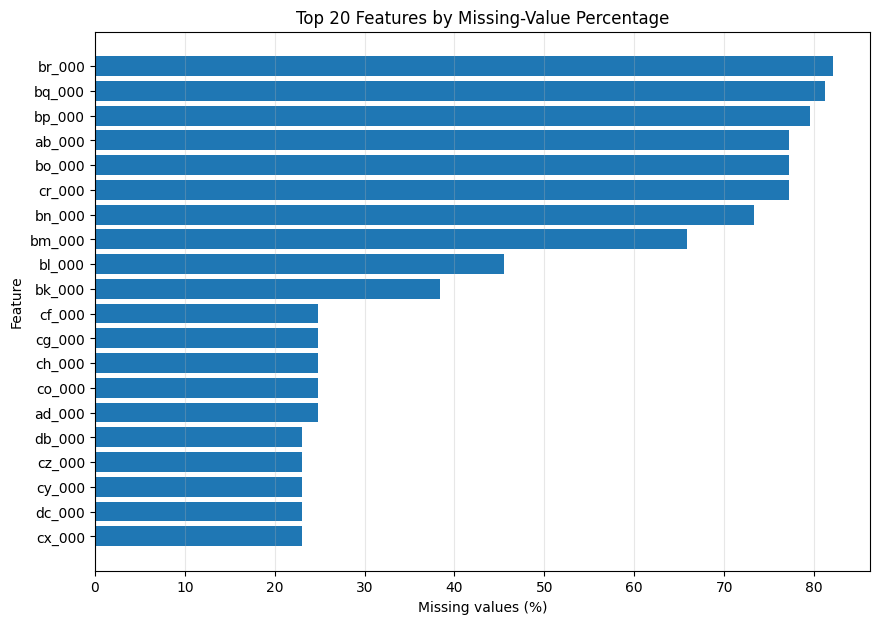

In [ ]:
top_missing = (
    missing_summary
    .head(20)
    .sort_values("missing_percentage")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_missing.index,
    top_missing["missing_percentage"]
)

plt.xlabel("Missing values (%)")
plt.ylabel("Feature")
plt.title("Top 20 Features by Missing-Value Percentage")
plt.grid(axis="x", alpha=0.3)
plt.show()

In [ ]:
duplicates_before = df.duplicated().sum()

df = df.drop_duplicates().reset_index(drop=True)

duplicates_removed = (
    original_rows - len(df)
)

print("Duplicate rows identified:",
      duplicates_before)
print("Duplicate rows removed:",
      duplicates_removed)
print("Rows after duplicate removal:",
      len(df))

Duplicate rows identified: 0
Duplicate rows removed: 0
Rows after duplicate removal: 60000


In [ ]:
feature_columns = [
    column for column in df.columns
    if column != "class"
]

for column in feature_columns:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce"
    )

df["class"] = df["class"].astype("string")

print("Data-type counts after correction:")
display(df.dtypes.value_counts())

Data-type counts after correction:


,count
float64,169
string[python],1
int64,1


In [ ]:
missing_threshold = 40

feature_missing_percentage = (
    df[feature_columns].isna().mean() * 100
)

high_missing_columns = (
    feature_missing_percentage[
        feature_missing_percentage >
        missing_threshold
    ]
    .index
    .tolist()
)

print("Columns removed for excessive missingness:",
      len(high_missing_columns))
print(high_missing_columns)

df = df.drop(columns=high_missing_columns)

Columns removed for excessive missingness: 9
['ab_000', 'bl_000', 'bm_000', 'bn_000', 'bo_000', 'bp_000', 'bq_000', 'br_000', 'cr_000']


In [ ]:
feature_columns = [
    column for column in df.columns
    if column != "class"
]

constant_columns = [
    column
    for column in feature_columns
    if df[column].nunique(dropna=True) <= 1
]

print("Constant columns identified:",
      len(constant_columns))
print(constant_columns)

df = df.drop(columns=constant_columns)

Constant columns identified: 1
['cd_000']


In [ ]:
feature_columns = [
    column for column in df.columns
    if column != "class"
]

missing_before_imputation = (
    df[feature_columns].isna().sum().sum()
)

median_values = df[feature_columns].median()

df[feature_columns] = (
    df[feature_columns]
    .fillna(median_values)
)

missing_after_imputation = (
    df[feature_columns].isna().sum().sum()
)

print("Missing values before imputation:",
      missing_before_imputation)
print("Missing values after imputation:",
      missing_after_imputation)

Missing values before imputation: 453787
Missing values after imputation: 0


In [ ]:
median_values.to_csv(
    "data/cleaned/imputation_medians.csv",
    header=["median"]
)

In [ ]:
print("Classes before encoding:")
print(df["class"].value_counts())

df["class"] = df["class"].map({
    "neg": 0,
    "pos": 1
})

if df["class"].isna().any():
    raise ValueError(
        "Unexpected target-category value found."
    )

df["class"] = df["class"].astype("int8")

print("\nClasses after encoding:")
print(df["class"].value_counts())

Classes before encoding:
class
neg    59000
pos     1000
Name: count, dtype: Int64

Classes after encoding:
class
0    59000
1     1000
Name: count, dtype: int64


In [ ]:
feature_columns = [
    column for column in df.columns
    if column != "class"
]

q1 = df[feature_columns].quantile(0.25)
q3 = df[feature_columns].quantile(0.75)
iqr = q3 - q1

lower_limits = q1 - 1.5 * iqr
upper_limits = q3 + 1.5 * iqr

outlier_mask = (
    df[feature_columns].lt(
        lower_limits,
        axis=1
    ) |
    df[feature_columns].gt(
        upper_limits,
        axis=1
    )
)

outlier_counts = (
    outlier_mask
    .sum()
    .sort_values(ascending=False)
)

print("Top features by IQR outlier count:")
display(outlier_counts.head(20))

Top features by IQR outlier count:


,0
az_007,14235
cl_000,13660
dr_000,13007
dq_000,12870
ba_008,12781
cj_000,12540
aj_000,12452
ag_003,12435
dy_000,12401
bk_000,12287


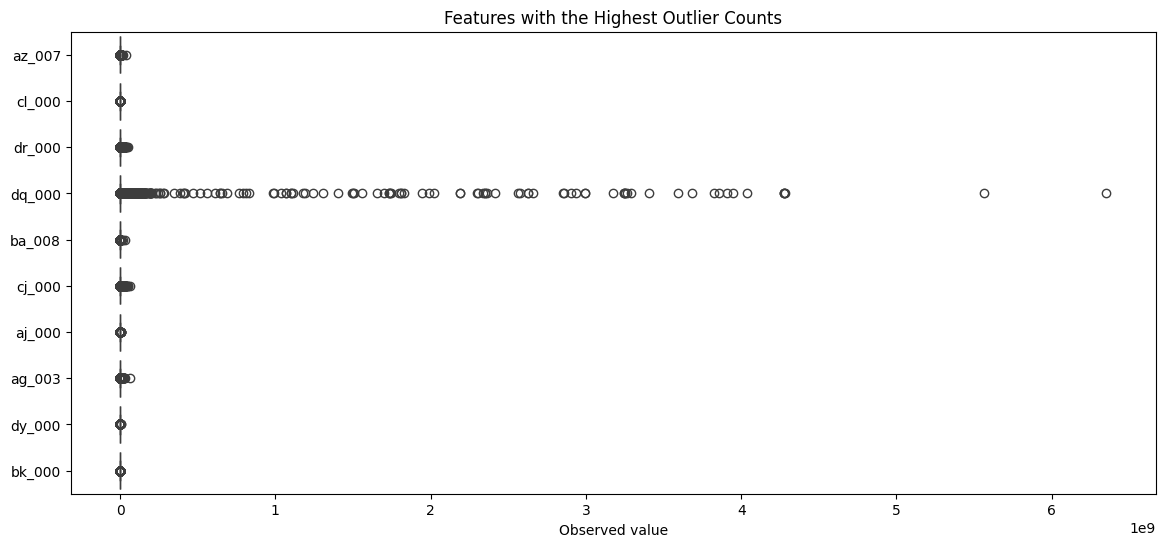

In [ ]:
selected_features = (
    outlier_counts
    .head(10)
    .index
    .tolist()
)

plt.figure(figsize=(14, 6))

sns.boxplot(
    data=df[selected_features],
    orient="h"
)

plt.title("Features with the Highest Outlier Counts")
plt.xlabel("Observed value")
plt.show()

In [ ]:
values_capped = int(outlier_mask.sum().sum())

df[feature_columns] = (
    df[feature_columns]
    .clip(
        lower=lower_limits,
        upper=upper_limits,
        axis=1
    )
)

print("Extreme values treated using IQR capping:",
      values_capped)
print("Rows deleted during outlier treatment: 0")

#Standardize numerical features

scaler = StandardScaler()

df[feature_columns] = scaler.fit_transform(
    df[feature_columns]
)

print("Numerical features standardized")

scaling_check = pd.DataFrame({
    "mean_after_scaling":
        df[feature_columns].mean(),
    "std_after_scaling":
        df[feature_columns].std()
})

display(scaling_check.head(15).round(3))

Extreme values treated using IQR capping: 906880
Rows deleted during outlier treatment: 0
Numerical features standardized


,mean_after_scaling,std_after_scaling
aa_000,0.0,1.0
ac_000,-0.0,1.0
ad_000,0.0,1.0
ae_000,0.0,0.0
af_000,0.0,0.0
ag_000,0.0,0.0
ag_001,0.0,0.0
ag_002,0.0,0.0
ag_003,0.0,0.0
ag_004,-0.0,1.0


In [ ]:
cleaned_rows, cleaned_columns = df.shape

remaining_constant_columns = [
    column
    for column in feature_columns
    if df[column].nunique(dropna=False) <= 1
]

print("FINAL DATA-QUALITY REPORT")
print("-------------------------")
print("Original dimensions:",
      (original_rows, original_columns))
print("Cleaned dimensions:",
      (cleaned_rows, cleaned_columns))
print("Rows removed:",
      original_rows - cleaned_rows)
print("Columns removed:",
      original_columns - cleaned_columns)
print("Remaining missing values:",
      df.isna().sum().sum())
print("Remaining duplicates:",
      df.duplicated().sum())
print("Remaining constant columns:",
      remaining_constant_columns)
print("Encoded target type:",
      df["class"].dtype)

print("\nFinal class distribution:")
display(df["class"].value_counts())

display(df.head())

FINAL DATA-QUALITY REPORT
-------------------------
Original dimensions: (60000, 171)
Cleaned dimensions: (60000, 161)
Rows removed: 0
Columns removed: 10
Remaining missing values: 0
Remaining duplicates: 367
Remaining constant columns: ['ae_000', 'af_000', 'ag_000', 'ag_001', 'ag_002', 'ag_003', 'ai_000', 'aj_000', 'ak_000', 'ar_000', 'as_000', 'at_000', 'au_000', 'ay_000', 'ay_001', 'ay_002', 'ay_003', 'ay_004', 'ay_009', 'az_007', 'az_008', 'az_009', 'ch_000', 'cj_000', 'cl_000', 'cn_000', 'cn_001', 'cs_009', 'cy_000', 'da_000', 'df_000', 'dg_000', 'dh_000', 'di_000', 'dj_000', 'dk_000', 'dl_000', 'dm_000', 'dq_000', 'dr_000', 'dz_000', 'ea_000', 'ef_000', 'eg_000']
Encoded target type: int8

Final class distribution:


,count
class,
0,59000
1,1000


,class,aa_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,ag_003,ag_004,ag_005,ag_006,ag_007,ag_008,...,eb_000,ec_00,ed_000,ee_000,ee_001,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,0,1.085094,1.901712,0.324056,0.0,0.0,0.0,0.0,0.0,0.0,0.135946,1.160914,1.781007,1.466975,0.434726,...,0.182175,1.968602,1.938105,1.317496,2.307921,2.391171,2.131954,1.173469,0.681945,0.736317,0.367309,-0.070031,-0.619801,0.0,0.0
1,0,-0.055569,-0.734296,-0.378097,0.0,0.0,0.0,0.0,0.0,0.0,-0.284005,0.114167,0.368796,0.374443,0.685638,...,0.400321,1.674602,1.518495,0.631422,0.726018,0.388552,0.207558,-0.036829,-0.066453,-0.202292,-0.191859,0.132239,0.151913,0.0,0.0
2,0,0.153065,-0.446732,-0.496642,0.0,0.0,0.0,0.0,0.0,0.0,-0.651119,-0.265423,0.486937,-0.123553,-0.171375,...,-0.385585,0.175809,0.059854,-0.284837,0.002893,-0.047375,0.096166,0.332951,0.481057,0.652231,0.367789,0.111906,-0.355360,0.0,0.0
3,0,-0.919326,-0.646009,-0.651662,0.0,0.0,0.0,0.0,0.0,0.0,-0.638651,-0.758686,-0.880326,-0.775423,-0.696080,...,-0.720917,-1.102445,-1.012481,-0.868466,-0.878277,-0.886217,-0.878885,-0.866583,-0.884882,-0.812697,-0.782502,-0.678235,-0.619801,0.0,0.0
4,0,0.671486,0.991091,1.135634,0.0,0.0,0.0,0.0,0.0,0.0,0.279688,1.877598,0.426597,-0.482471,-0.495735,...,1.925808,0.298188,0.233026,0.040049,0.882190,0.995765,0.523241,0.280056,0.273004,0.497890,1.485440,2.160898,0.006831,0.0,0.0


In [ ]:
cleaned_csv = (
    "data/cleaned/"
    "aps_failure_cleaned.csv"
)

df.to_csv(
    cleaned_csv,
    index=False,
    float_format="%.6f"
)

print("Saved:", cleaned_csv)

Saved: data/cleaned/aps_failure_cleaned.csv


In [ ]:
cleaning_summary = pd.DataFrame({
    "metric": [
        "Original rows",
        "Original columns",
        "Original missing values",
        "Duplicate rows removed",
        "High-missing columns removed",
        "Constant columns removed",
        "Missing values imputed",
        "Extreme values capped",
        "Final rows",
        "Final columns",
        "Final missing values",
        "Final duplicate rows"
    ],
    "value": [
        original_rows,
        original_columns,
        df_raw.isna().sum().sum(),
        duplicates_removed,
        len(high_missing_columns),
        len(constant_columns),
        missing_before_imputation,
        values_capped,
        cleaned_rows,
        cleaned_columns,
        df.isna().sum().sum(),
        df.duplicated().sum()
    ]
})

display(cleaning_summary)

cleaning_summary.to_csv(
    "data/cleaned/cleaning_summary.csv",
    index=False
)

,metric,value
0,Original rows,60000
1,Original columns,171
2,Original missing values,850015
3,Duplicate rows removed,0
4,High-missing columns removed,9
5,Constant columns removed,1
6,Missing values imputed,453787
7,Extreme values capped,906880
8,Final rows,60000
9,Final columns,161


In [ ]:
from google.colab import files

files.download(raw_copy)
files.download(cleaned_csv)

files.download(
    "data/cleaned/cleaning_summary.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
median_values.to_csv(
    "imputation_medians.csv",
    header=["median"]
)

from google.colab import files
files.download("imputation_medians.csv")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
scaler_parameters = pd.DataFrame({
    "feature": feature_columns,
    "mean": scaler.mean_,
    "scale": scaler.scale_
})

scaler_parameters.to_csv(
    "scaler_parameters.csv",
    index=False
)

files.download("scaler_parameters.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
import gzip
import shutil

with open(
    "/content/aps_dataset/aps_failure_training_set.csv",
    "rb"
) as source:
    with gzip.open(
        "aps_failure_training_set.csv.gz",
        "wb"
    ) as destination:
        shutil.copyfileobj(source, destination)

from google.colab import files
files.download("aps_failure_training_set.csv.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import gzip
import shutil

with open(
    "/content/data/cleaned/aps_failure_cleaned.csv",
    "rb"
) as source:
    with gzip.open(
        "aps_failure_cleaned.csv.gz",
        "wb"
    ) as destination:
        shutil.copyfileobj(source, destination)

from google.colab import files
files.download("aps_failure_cleaned.csv.gz")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>